#Introduction





In this project, we implemented a Naive Bayes text classifier from scratch.This helped us in understanding the fundamentals of probabilistic text classification.
The model was applied to two real-world datasets:

**SMS Spam Collection**:  
The SMS Spam Collection is a dataset of real text messages. Each message is labeled as either “spam” (unwanted promotional messages) or “ham” (legitimate messages). It is used for binary text classification. This helps models tell the difference between spam and normal SMS messages.

**BBC News Articles**:  
The BBC News Dataset includes several news articles that are categorized into five topics: business, entertainment, politics, sport, and technology. It is used for multi-class text classification. The goal is to predict the topic of each article based on its content.


This project involves data processing, training, prediction, evaluation, and analysis.
In Naive, we assume that all features (words) are independent of each other given the class.

# **SMS** **Spam** **Collection**

## Data Loading and Preprocessing


1) **Download the dataset**: The code downloads the SMS Spam Collection dataset (a ZIP file) using the requests library.

2) **Extract the data file**: The ZIP file is extracted to get the text file named SMSSpamCollection, which contains labeled SMS messages (spam or ham).

3) **Load into DataFrame**:Using pandas the text file is read into a DataFrame with two columns:

*   label: whether the message is "ham" or "spam".
*   text: the SMS message content.

4) **Pre-processing(cleaning and tokenizing)**: The preprocess() function converts text to lowercase, removes punctuations and splits text into tokens(individual words). This is stored in a new column processed_text.

5) **Building Vocabulary**: The code collects all tokens from every message, then creates a set of unique words called the vocabulary. It prints the tiral number of tokens across all messages and the size of the vocabulary.
6) **Split into Training and Test set**: The last 2.5% of each category is for Test Set and remaining for Training Set.

In [1]:
import requests
import os

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_file_path = "smsspamcollection.zip"

response = requests.get(url)
with open(zip_file_path, "wb") as f:
    f.write(response.content)

print(f"Downloaded {zip_file_path}")

Downloaded smsspamcollection.zip


In [2]:
import zipfile

zip_file_path = "smsspamcollection.zip"
extracted_file_path = "SMSSpamCollection"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract(extracted_file_path)

print(f"Extracted {extracted_file_path}")

Extracted SMSSpamCollection


In [3]:
import pandas as pd

df = pd.read_csv("SMSSpamCollection", sep="\t", names=["label","text"])

# Split the DataFrame into training and testing sets by category (last 2.5% of each category for test)
test_df = pd.DataFrame()
training_df = pd.DataFrame()

for label in df['label'].unique():
    label_df = df[df['label'] == label]
    split_index = int(len(label_df) * 0.975) # Keep 97.5% for training
    training_df = pd.concat([training_df, label_df.iloc[:split_index]])
    test_df = pd.concat([test_df, label_df.iloc[split_index:]])

df = training_df.copy() # Update df to be the training set

In [4]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [5]:
import string
def preprocess(text):
  text = text.lower()
  translator = str.maketrans('', '', string.punctuation)
  text = text.translate(translator)
  tokens = text.split()
  return tokens


In [6]:
df['processed_text'] = df['text'].apply(preprocess)

In [7]:
df.head()

,label,text,processed_text
0,ham,"Go until jurong point, crazy.. Available only ...","[go, until, jurong, point, crazy, available, o..."
1,ham,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
3,ham,U dun say so early hor... U c already then say...,"[u, dun, say, so, early, hor, u, c, already, t..."
4,ham,"Nah I don't think he goes to usf, he lives aro...","[nah, i, dont, think, he, goes, to, usf, he, l..."
6,ham,Even my brother is not like to speak with me. ...,"[even, my, brother, is, not, like, to, speak, ..."


In [8]:
words = []
for tokens_list in df['processed_text']:
  words.extend(tokens_list)


vocab = set(words)


In [9]:
print(f"Total number of tokens (words) found: {len(words)}")
print(f"Size of the vocabulary (unique words): {len(vocab)}")

Total number of tokens (words) found: 83596
Size of the vocabulary (unique words): 9527


## (a) Prior Probabilities P(C) of Spam and Ham

In [10]:
num_spam_docs = len(df[df['label'] == 'spam'])
num_ham_docs = len(df[df['label'] == 'ham'])

class_doc_counts = {'spam': num_spam_docs, 'ham': num_ham_docs}

print(class_doc_counts)

def prior_probability(class_name, class_doc_counts):
    total_docs = sum(class_doc_counts.values())
    return class_doc_counts[class_name] / total_docs

print("P(spam) =", prior_probability('spam', class_doc_counts))
print("P(ham)  =", prior_probability('ham', class_doc_counts))

{'spam': 728, 'ham': 4704}
P(spam) = 0.13402061855670103
P(ham)  = 0.865979381443299


## (b) Likelihood P(w_d | C) : For SMS dataset we use the Binary ON/OFF (Presence-Based) model



In [11]:
from collections import defaultdict
import math

def compute_likelihoods(texts, labels, vocab, class_doc_counts, alpha=1.0):
    #P(w|C) for all words and both classes (binary ON/OFF model).

    # Counting how many documents in each class contain each word
    doc_counts = {c: defaultdict(int) for c in class_doc_counts}

    for tokens, label in zip(texts, labels):
        unique_tokens = set(tokens)  # we only want unique words,as we need to see only if the words are present or not.
        for w in unique_tokens:
            if w in vocab:
                doc_counts[label][w] += 1

    likelihoods = {c: {} for c in class_doc_counts}
    for c in class_doc_counts:
        N_c = class_doc_counts[c]
        for w in vocab:
            count = doc_counts[c].get(w, 0)
            # Formula for calculating Likelihood using Binary ON/OFF Model
            likelihoods[c][w] = (count + alpha) / (N_c + 2 * alpha)

    return likelihoods

# likelihoods : dict :- {class: {word: P(w|class)}}
likelihoods = compute_likelihoods(df['processed_text'], df['label'], vocab, class_doc_counts, alpha=1.0)

#Printing some words for example
print("P('free' | spam) =", likelihoods['spam'].get('free', 0))
print("P('meeting' | ham) =", likelihoods['ham'].get('meeting', 0))

def binary_indicator(word, document):
    return 1 if word in document else 0

def document_likelihood(document, class_name, likelihoods):
    doc_likelihood = 1.0
    document_set = set(document)

    for word in likelihoods[class_name]:
        indicator = binary_indicator(word, document_set)
        p_w_c = likelihoods[class_name][word]

        if indicator == 1:
            doc_likelihood *= p_w_c
        else:
            doc_likelihood *= (1 - p_w_c)

    return doc_likelihood


P('free' | spam) = 0.22054794520547946
P('meeting' | ham) = 0.009349766255843604


In [12]:
#Example document and its likelihood of being spam.
example_document = ['free', 'win', 'cash', 'now']
example_class = 'spam'

# We are using likelihood dictionary from above.

doc_likelihood_for_spam = document_likelihood(example_document, example_class, likelihoods)

print(f"Likelihood of the document being {example_class}: {doc_likelihood_for_spam}")

Likelihood of the document being spam: 1.2492611327694665e-19


## (c) Posterior scores log P(C | w_d)

In [13]:
import math

def score(class_name, document_words, prior_probabilities, likelihoods):
    log_prior = math.log(prior_probabilities[class_name])

    log_likelihood_sum = 0.0
    for word in document_words:
        # We are using 1e-9 to avoid log(0).
        log_likelihood_sum += math.log(likelihoods[class_name].get(word, 1e-9))

    return log_prior + log_likelihood_sum



In [14]:
# Example document and its score for being spam
example_document_words = ['free', 'win', 'cash', 'now']
example_class_name = 'spam'

prior_probabilities = {'spam': prior_probability('spam', class_doc_counts),'ham': prior_probability('ham', class_doc_counts)}

spam_score = score(example_class_name, example_document_words, prior_probabilities, likelihoods)

print(f"Score for the document being {example_class_name}: {spam_score}")

Score for the document being spam: -9.902637931706678


##  Choosing the Class

In [15]:
def classify_document(document_words, prior_probabilities, likelihoods):
    spam_score = score('spam', document_words, prior_probabilities, likelihoods)
    ham_score = score('ham', document_words, prior_probabilities, likelihoods)

    if spam_score > ham_score:
        return 'spam'
    else:
        return 'ham'

## Test Cases, Test Set, Accuracy and top 10 most indicative words for each class

First we will use the 4 test cases given in the Question:

In [16]:
# Test cases:-
test1="Win free tickets now!!!"
test2="Are you coming to the meeting?"
test3="URGENT! You won $1000"
test4="See you tomorrow at lunch"
test5 = "Hey there ! You Wan Z000 dollars"

test_cases = [test1, test2, test3, test4, test5]
expected_class = ['spam', 'ham', 'spam', 'ham', 'spam']
accuracy_number=0
for i, test_case in enumerate(test_cases):
    # Preprocessing each test case
    processed_test_case = preprocess(test_case)
    #Predicting which class to be chosen using the functions defined above.
    predicted_class = classify_document(processed_test_case, prior_probabilities, likelihoods)

    print(f"'{test_case}' :- Predicted Class: {predicted_class}")
    if(predicted_class==expected_class[i]):
      accuracy_number+=1

print(f"Accuracy: {accuracy_number/len(test_cases)}")

'Win free tickets now!!!' :- Predicted Class: spam
'Are you coming to the meeting?' :- Predicted Class: ham
'URGENT! You won $1000' :- Predicted Class: spam
'See you tomorrow at lunch' :- Predicted Class: ham
'Hey there ! You Wan Z000 dollars' :- Predicted Class: ham
Accuracy: 0.8


The test set we chose (last 2.5% of each category for test):

In [17]:
# Evaluate the model on the test_df
correct_predictions_test = 0
total_test_cases = len(test_df)

for index, row in test_df.iterrows():
    text = row['text']
    actual_label = row['label']

    # Preprocess the text
    processed_text_test = preprocess(text)


    predicted_label = classify_document(processed_text_test, prior_probabilities, likelihoods)


    if predicted_label == actual_label:
        correct_predictions_test += 1

# Calculate accuracy
accuracy_test = correct_predictions_test / total_test_cases

print(f"Accuracy on the test set: {accuracy_test}")

Accuracy on the test set: 0.9071428571428571


In [18]:
import pandas as pd

#To calculate the top 10 most indicative words for spam and ham we will calculate the ratio of likelihoods for each word
word_likelihood_ratios = {}
for word in vocab:
    likelihood_spam = likelihoods['spam'].get(word, 1e-9)
    likelihood_ham = likelihoods['ham'].get(word, 1e-9)

    #To Avoid division by zero we add 1e-9 to the denominator
    ratio_spam_to_ham = likelihood_spam / (likelihood_ham + 1e-9)
    ratio_ham_to_spam = likelihood_ham / (likelihood_spam + 1e-9)

    word_likelihood_ratios[word] = {'spam_to_ham': ratio_spam_to_ham, 'ham_to_spam': ratio_ham_to_spam}

# Converting word_likelihood to DataFrame to make the sorting easier.
ratios_df = pd.DataFrame.from_dict(word_likelihood_ratios, orient='index')

#For top 10 most indicative words for spam:
top_10_spam_indicative = ratios_df.sort_values(by='spam_to_ham', ascending=False).head(10)

#For top 10 most indicative words for ham:
top_10_ham_indicative = ratios_df.sort_values(by='ham_to_spam', ascending=False).head(10)

print("Top 10 Most Indicative Words for Spam:")
display(top_10_spam_indicative[['spam_to_ham']])

print("\nTop 10 Most Indicative Words for Ham:")
display(top_10_ham_indicative[['ham_to_spam']])

Top 10 Most Indicative Words for Spam:


,spam_to_ham
claim,676.887226
prize,535.063235
won,457.704695
guaranteed,322.327250
18,283.647980
tone,270.754890
awarded,244.968710
£1000,219.182530
150ppm,212.735985
£2000,206.289440



Top 10 Most Indicative Words for Ham:


,ham_to_spam
ltgt,32.420291
lor,21.561820
ü,20.631094
he,20.631094
later,19.700368
da,17.838916
ill,17.683801
she,14.116012
thats,13.805770
doing,13.030165


# **BBC News Dataset**


## Data Loading and preprocessing


1) **Download the dataset**: the dataset was downloaded from Kaggle. The path variable then holds the location of the downloaded files.

2) **Extract the data file**: The dataset downloaded from Kaggle usually comes in a compressed format, such as a zip file. The kagglehub.dataset_download function automatically extracts it to the specified path.
The code then goes through the extracted directories, which include 'BBC News Summary', 'News Articles', 'Summaries', and the nested 'bbc news summary/BBC News Summary', to locate all the individual text files (.txt) containing the news articles.

3) **Load into DataFrame**:The code reads each found text file and extracts the content anThis information is then appended to a list called data.d the category (from the directory structure). Finally,
bbc_df = pd.DataFrame(data) converts this list into a pandas DataFrame with 'text' and 'category' columns.

4) **Pre-processing(cleaning and tokenizing)**:  The preprocess() function, which was defined earlier for the SMS dataset, is applied to the 'text' column of the bbc_df DataFrame.
This function converts the text to lowercase, removes punctuation, and splits the text into individual words (tokens), storing the result in a new column called 'processed_text'.

5) **Building Vocabulary**: The code builds the vocabulary by going through the processed_text column of the bbc_df. It collects all the tokens from each processed document and creates a set of unique words from those tokens. This set, saved in vocab_BBC, represents the vocabulary of the entire dataset. Finally, the size of this vocabulary is printed.
6) **Split into Training and Test set**: The last 1% of each category is for Test Set and remaining for Training Set.

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pariza/bbc-news-summary")

print("Path to dataset files:", path)

100%|██████████| 8.91M/8.91M [00:00<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pariza/bbc-news-summary/versions/2


In [20]:
import os
import pandas as pd

# The path to the extracted dataset files is stored in the 'path' variable
# Recursively find all text files in the extracted directory and its subdirectories
all_files = []
for root, dirs, files in os.walk(os.path.join(path, 'BBC News Summary', 'News Articles')):
    for file in files:
        if file.endswith('.txt'):
            all_files.append(os.path.join(root, file))

for root, dirs, files in os.walk(os.path.join(path, 'BBC News Summary', 'Summaries')):
    for file in files:
        if file.endswith('.txt'):
            all_files.append(os.path.join(root, file))

# Also search in the nested 'bbc news summary/BBC News Summary' directory
for root, dirs, files in os.walk(os.path.join(path, 'bbc news summary', 'BBC News Summary', 'News Articles')):
    for file in files:
        if file.endswith('.txt'):
            all_files.append(os.path.join(root, file))

for root, dirs, files in os.walk(os.path.join(path, 'bbc news summary', 'BBC News Summary', 'Summaries')):
    for file in files:
        if file.endswith('.txt'):
            all_files.append(os.path.join(root, file))




# Create an empty list to store data
data = []


for file_path in all_files:
    with open(file_path, 'r', encoding='latin-1') as f: # Use latin-1 encoding
        content = f.read()
        # Extract category from the directory name
        category = os.path.basename(os.path.dirname(file_path))
        data.append({'text': content, 'category': category})



bbc_df = pd.DataFrame(data)

# Split the DataFrame into training and testing sets by category (last 1% of each category for test)
test_bbc_df = pd.DataFrame()
training_bbc_df = pd.DataFrame()

for category in bbc_df['category'].unique():
    category_df = bbc_df[bbc_df['category'] == category]
    split_index = int(len(category_df) * 0.99)
    training_bbc_df = pd.concat([training_bbc_df, category_df.iloc[:split_index]])
    test_bbc_df = pd.concat([test_bbc_df, category_df.iloc[split_index:]])

bbc_df = training_bbc_df.copy() # Update bbc_df to be the training set

display(bbc_df.head())
display(test_bbc_df.head())

,text,category
0,Jobs growth still slow in the US\n\nThe US cre...,business
1,Libya takes $1bn in unfrozen funds\n\nLibya ha...,business
2,US regulator to rule on pain drug\n\nUS food a...,business
3,Survey confirms property slowdown\n\nGovernmen...,business
4,BBC poll indicates economic gloom\n\nCitizens ...,business


,text,category
7164,"House prices have risen 0.9% this year, Nation...",business
7165,"US oil prices have fallen by 6%, driven down b...",business
7166,"""With this new order and new pricing in place,...",business
7167,Gazprom is set to merge with state oil firm Ro...,business
7168,The BDO optimism index - a leading indicator o...,business


In [21]:
# Apply the preprocess function to the 'text' column of the bbc_df
bbc_df['processed_text'] = bbc_df['text'].apply(preprocess)

display(bbc_df.head())

,text,category,processed_text
0,Jobs growth still slow in the US\n\nThe US cre...,business,"[jobs, growth, still, slow, in, the, us, the, ..."
1,Libya takes $1bn in unfrozen funds\n\nLibya ha...,business,"[libya, takes, 1bn, in, unfrozen, funds, libya..."
2,US regulator to rule on pain drug\n\nUS food a...,business,"[us, regulator, to, rule, on, pain, drug, us, ..."
3,Survey confirms property slowdown\n\nGovernmen...,business,"[survey, confirms, property, slowdown, governm..."
4,BBC poll indicates economic gloom\n\nCitizens ...,business,"[bbc, poll, indicates, economic, gloom, citize..."


In [22]:
# Create a dictionary to store processed text for each category
category_processed_texts = {}

# Iterate through the DataFrame and group processed text by category
for index, row in bbc_df.iterrows():
    category = row['category']
    processed_text = row['processed_text']

    if category not in category_processed_texts:
        category_processed_texts[category] = []

    category_processed_texts[category].append(processed_text)

In [23]:
# Build vocabulary: all unique words across all categories
vocab_BBC= sorted(set(
    word
    for docs in category_processed_texts.values()
    for doc in docs
    for word in doc
))

print("Vocabulary size:", len(vocab_BBC))

Vocabulary size: 46773


In [24]:
total_words_per_class = {}

for category, docs in category_processed_texts.items():
    all_words = [w for doc in docs for w in doc]
    total_words_per_class[category] = len(all_words)

print(total_words_per_class)

{'business': 472550, 'politics': 536145, 'sport': 478564, 'entertainment': 362401, 'tech': 569438}


## (a) Prior Probabilities P(C) of every class


In [25]:
def compute_priorProbability_multinomial(bbc_dict):
    priors = {}
    total_docs = sum(len(docs) for docs in bbc_dict.values())
    for c, docs in bbc_dict.items():
        priors[c] = len(docs) / total_docs
    return priors

priors = compute_priorProbability_multinomial(category_processed_texts)

print("Prior Probabilities:")
for category, probability in priors.items():
    print(f"P({category}): {probability}")

Prior Probabilities:
P(business): 0.22922343324250682
P(politics): 0.18744323342415986
P(sport): 0.22967756584922797
P(entertainment): 0.1734786557674841
P(tech): 0.18017711171662126


## (b) Likelihood P(w_d|C) : For BBC News Datase we use the Multinomial (Count-Based) Model

In [26]:
from collections import Counter, defaultdict

def compute_likelihoods_multinomial(category_processed_texts, vocab_BBC, alpha=1.0):
    #Calculating P(w|C) for all the classes
    likelihoods_BBC = {}
    vocab_size = len(vocab_BBC)

    for c, docs in category_processed_texts.items():
        all_words = [w for doc in docs for w in doc] #This is done to flatten the list, so we get a list of all the words in the class.
        word_counts = Counter(all_words) #Counter() is used to get the frequency of each word in that class.
        total_words = sum(word_counts.values())

        likelihoods_BBC[c] = {}
        for w in vocab:
            count_w = word_counts.get(w, 0)
            # Formula for calculating Likelihood using Multinomial (Count-Based) Model
            likelihoods_BBC[c][w] = (count_w + alpha) / (total_words + alpha * vocab_size)

    return likelihoods_BBC

likelihoods_BBC = compute_likelihoods_multinomial(category_processed_texts, vocab_BBC, alpha=1.0)

# Printing some word likelihoods for example
print("P('business' | tech) =", likelihoods_BBC['tech'].get('business', 0))
print("P('football' | sport) =", likelihoods_BBC['sport'].get('football', 0))

P('business' | tech) = 0.0003261869716704181
P('football' | sport) = 0.0007442841452248747


In [27]:
def document_likelihood_BBC(document, class_name, likelihoods_BBC):
    doc_likelihood = 1.0
    document_set = set(document)

    for word in likelihoods_BBC[class_name]:
        indicator = binary_indicator(word, document_set)
        p_w_c = likelihoods_BBC[class_name][word]

        if indicator == 1:
            doc_likelihood *= p_w_c
        else:
            doc_likelihood *= (1 - p_w_c)

    return doc_likelihood

# Example document and its likelihood of being of class business
example_document_bbc = ['business', 'growth', 'economy']
example_class_bbc = 'business'

doc_likelihood_bbc = document_likelihood_BBC(example_document_bbc, example_class_bbc, likelihoods_BBC)

print(f"Likelihood of the document being {example_class_bbc}: {doc_likelihood_bbc}")


Likelihood of the document being business: 0.0006114586091741845


## (c) Posterior scores log P(C | w_d)

The function for this is already defined in the earlier database(SMS)

In [28]:
# Example document and its words for calculating the score
example_document_words_bbc = ['business', 'stock', 'market']
example_class_name_bbc = 'business'

# Prior probabilities for BBC News dataset
prior_probabilities_bbc = compute_priorProbability_multinomial(category_processed_texts)


# Calculate the score for the example document being of the example class
bbc_score = score(example_class_name_bbc, example_document_words_bbc, prior_probabilities_bbc, likelihoods_BBC)

print(f"Score for the document being {example_class_name_bbc}: {bbc_score}")

Score for the document being business: -21.257407178653068


## Choosing the class

In [29]:
#The predicted class is the one with the largest score.
def predict_class_multinomial(document_words, prior_probabilities, likelihoods):
    scores = {}
    for class_name in prior_probabilities.keys():
        scores[class_name] = score(class_name, document_words, prior_probabilities_bbc, likelihoods)

    predicted_class = max(scores, key=scores.get)
    return predicted_class

## Test Cases, Test Set and Accuracy

First we will use the 5 test cases given in the Question:

In [30]:
test_1="Stock market crashes as oil prices rise"
test_2="Premier League team wins the championship"
test_3="Government made new healthcare reform"
test_4="Apple releases latest iPhone with new features"
test_5="AI startup raises funding in Silicon Valley"

test_cases_bbc = [test_1, test_2, test_3, test_4, test_5]
expected_class_bbc = ['business', 'sport', 'politics', 'tech', 'business']

def predict_test_cases_bbc(test_cases, prior_probabilities, likelihoods):
    predictions = []
    for test_case in test_cases:
        # Preprocessing the test cases.
        processed_test_case = preprocess(test_case)

        # Calculate scores for all classes for the current test case
        scores = {}
        for class_name in prior_probabilities.keys():
            scores[class_name] = score(class_name, processed_test_case, prior_probabilities_bbc, likelihoods)

        # Predicting the class using the function defined above.
        predicted_class = predict_class_multinomial(processed_test_case, prior_probabilities, likelihoods)
        predictions.append({'text': test_case, 'predicted_class': predicted_class})
    return predictions


bbc_predictions = predict_test_cases_bbc(test_cases_bbc, prior_probabilities_bbc, likelihoods_BBC)

correct_predictions = 0
for i, prediction in enumerate(bbc_predictions):
    print(f"'{prediction['text']}' :- Predicted Class: {prediction['predicted_class']}")
    #Checking if the predicted class is equal to expected class.
    if prediction['predicted_class'] == expected_class_bbc[i]:
        correct_predictions += 1

#Calculating Accuracy
accuracy = correct_predictions / len(test_cases_bbc)
print(f"\nAccuracy: {accuracy}")

'Stock market crashes as oil prices rise' :- Predicted Class: business
'Premier League team wins the championship' :- Predicted Class: sport
'Government made new healthcare reform' :- Predicted Class: sport
'Apple releases latest iPhone with new features' :- Predicted Class: tech
'AI startup raises funding in Silicon Valley' :- Predicted Class: business

Accuracy: 0.8


The test set we chose (last 1% of each category for test):

In [31]:
# Evaluate the model on the test_bbc_df
correct_predictions_bbc_test = 0
total_test_cases_bbc = len(test_bbc_df)

for index, row in test_bbc_df.iterrows():
    text = row['text']
    actual_label_bbc = row['category']

    processed_text_bbc_test = preprocess(text)

    predicted_label_bbc = predict_class_multinomial(processed_text_bbc_test, prior_probabilities_bbc, likelihoods_BBC)

    if predicted_label_bbc == actual_label_bbc:
        correct_predictions_bbc_test += 1

# Calculate accuracy
accuracy_bbc_test = correct_predictions_bbc_test / total_test_cases_bbc

print(f"Accuracy on the BBC News test set: {accuracy_bbc_test}")

Accuracy on the BBC News test set: 0.9565217391304348


## Confusion Matrix

Confusion Matrix for the selectes Test Set(last 1% of each category for test:)

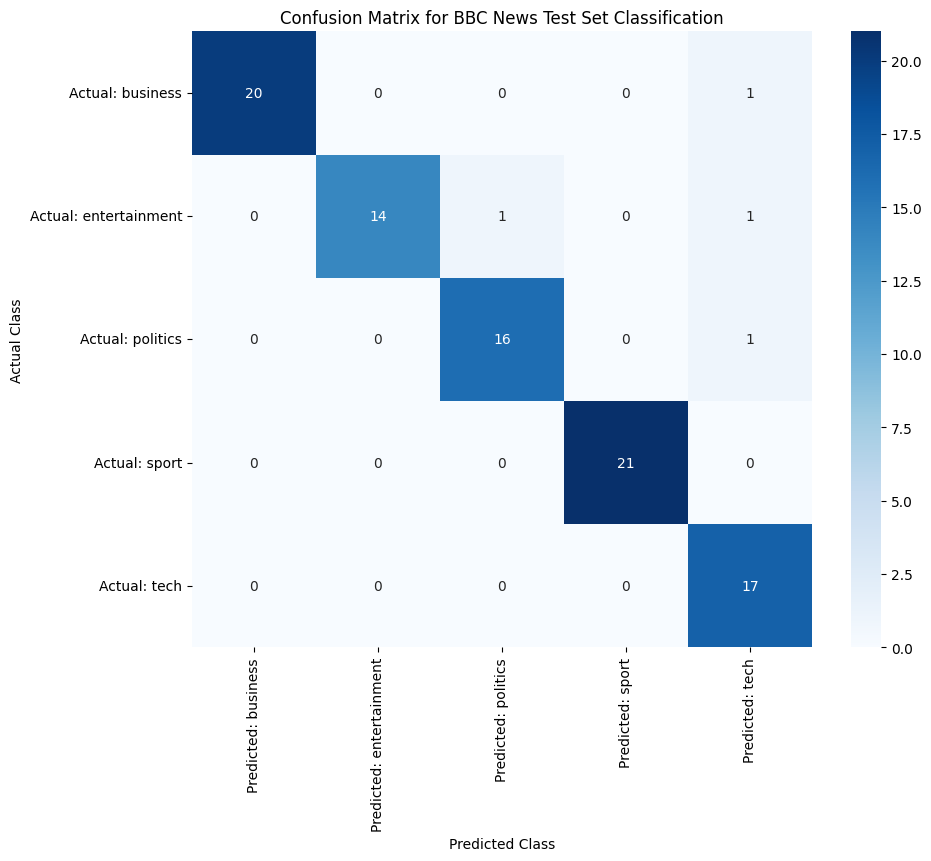

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the actual and predicted classes from the test_bbc_df
actual_classes_bbc_test = test_bbc_df['category'].tolist()
predicted_classes_bbc_test = []

for index, row in test_bbc_df.iterrows():
    text = row['text']
    processed_text_bbc_test = preprocess(text)
    predicted_label_bbc = predict_class_multinomial(processed_text_bbc_test, prior_probabilities_bbc, likelihoods_BBC)
    predicted_classes_bbc_test.append(predicted_label_bbc)

labels_bbc = sorted(list(set(actual_classes_bbc_test)))

# Calculate the confusion matrix
cm_bbc = confusion_matrix(actual_classes_bbc_test, predicted_classes_bbc_test, labels=labels_bbc)

# Create a DataFrame for better visualization
cm_bbc_df = pd.DataFrame(cm_bbc, index=[f'Actual: {label}' for label in labels_bbc], columns=[f'Predicted: {label}' for label in labels_bbc])

# Plot the Confusion Matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm_bbc_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for BBC News Test Set Classification')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

Confusion Matrix for the 5 test cases given in the question:

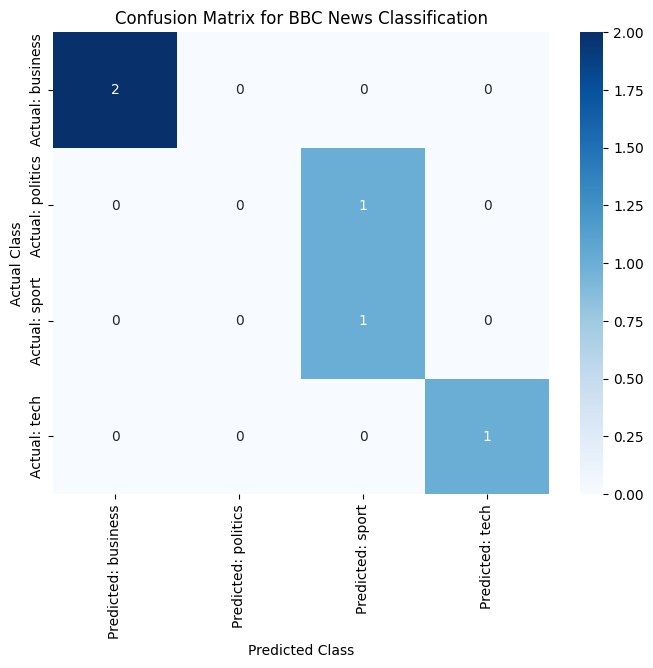

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the actual and predicted classes from the test cases
actual_classes = expected_class_bbc
predicted_classes = [prediction['predicted_class'] for prediction in bbc_predictions]

labels = sorted(list(set(actual_classes + predicted_classes)))

# Calculating the confusion matrix(The values of the confusion matrix).
cm = confusion_matrix(actual_classes, predicted_classes, labels=labels)

# Create a DataFrame for better visualization and then this dataframe is used to create the heatmap.
cm_df = pd.DataFrame(cm, index=[f'Actual: {label}' for label in labels], columns=[f'Predicted: {label}' for label in labels])

#Using Heatmap to plot the Confusion Matrix.
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for BBC News Classification')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

## Top 10 most indicative words for each class

In [34]:
import pandas as pd

# To calculate the top 10 most indicative words for each class we will calculate the ratio of likelihoods for each word
# We would use the logic that for a word to be indicative of a class, its likelihood in that class should be high compared to its likelihood in other classes.
# Therefore we would calculate the ratios for each class against all the other classes.
word_likelihood_ratios_bbc = {}
for word in vocab_BBC:
    likelihoods_for_word = {c: likelihoods_BBC[c].get(word, 1e-9) for c in likelihoods_BBC}
    # So, here we would calculate the ratio of the likelihood in a class to the average likelihood across all other classes.

    for class_name in likelihoods_for_word:
        likelihood_current_class = likelihoods_for_word[class_name]

        sum_likelihoods_other_classes = sum(
            likelihoods_for_word[other_class] for other_class in likelihoods_for_word if other_class != class_name
        )
        # Calculating the average likelihood in other classes
        avg_likelihood_other_classes = sum_likelihoods_other_classes / (len(likelihoods_for_word) - 1) if len(likelihoods_for_word) > 1 else 1e-9

        # Finding the ratio:- (Here we are using 1e-9 so that we could prevent division by 0)
        ratio = likelihood_current_class / (avg_likelihood_other_classes + 1e-9)

        if word not in word_likelihood_ratios_bbc:
            word_likelihood_ratios_bbc[word] = {}
        word_likelihood_ratios_bbc[word][class_name] = ratio


# To make the sorting easier we would convert word_likelihood_ratios_bbc to DataFrame.
ratios_bbc_df = pd.DataFrame.from_dict(word_likelihood_ratios_bbc, orient='index')

print("Top 10 Most Indicative Words for Each Class (BBC News):")

# For top 10 most indicative words for each class:
top_words_df = pd.DataFrame()
for class_name in ratios_bbc_df.columns:
    top_10_indicative = ratios_bbc_df.sort_values(by=class_name, ascending=False).head(10)
    top_words_df[class_name] = top_10_indicative.index.tolist()

# Display the combined table
top_words_df = top_words_df.reset_index(drop=True) #reseting the index to start with 1
top_words_df.index = top_words_df.index + 1
display(top_words_df)

Top 10 Most Indicative Words for Each Class (BBC News):


,business,politics,sport,entertainment,tech
1,sec,lib,rugby,festival,mobiles
2,oil,partys,cup,oscar,spam
3,bmw,dem,coach,actor,windows
4,tobacco,shadow,arsenal,starring,blog
5,stock,drinking,fa,angels,multimedia
6,accounting,nhs,tait,album,3g
7,gas,election,lions,comedy,wifi
8,imf,tb,d,chart,domain
9,nasdaq,party,p,musical,software
10,re,tuition,subs,pop,console


# Conclusion


Through this project, we gained a solid understanding of how Naive Bayes classifiers use basic probability and word patterns to categorize text.

We learned how to clean and prepare raw text data.

We calculated prior and likelihood probabilities and applied Bayes’ theorem to make predictions.

By building both the Binary (Bernoulli) and Multinomial Naive Bayes models from scratch, we explored how each works best for different kinds of text, such as short SMS messages and longer news articles.

Testing our models on real datasets showed that even with its simple assumptions, Naive Bayes can produce strong and reliable results for tasks like spam detection and news classification.

This shows just how simple yet powerful the Naive Bayes approach can be when applied to real-world language tasks.